<div style="
    background: linear-gradient(135deg, #141E30, #243B55);
    padding: 35px;
    border-radius: 18px;
    text-align: center;
    color: white;
">

<h1>🛒 Sales Performance Analysis</h1>

<h3 style="color:#64FFDA;">
Data Exploration, Cleaning, Feature Engineering & Reporting
</h3>

<p>
Python • Pandas • NumPy • Matplotlib • Seaborn
</p>

</div>

<div style="
    background: linear-gradient(90deg, #00695C, #26A69A);
    padding: 16px 22px;
    border-radius: 10px;
    color: white;
">

<h2 style="margin:0;">
📂 1. Data Loading & Understanding
</h2>

</div>

In [1]:
# Import libraries for data analysis and visualization
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
%matplotlib inline

In [2]:
# Load the sales dataset
Data = pd.read_csv('sales_data.csv')

In [3]:
# Display the first five rows
Data.head()

,Product_ID,Sale_Date,Sales_Rep,Region,Sales_Amount,Quantity_Sold,Product_Category,Unit_Cost,Unit_Price,Customer_Type,Discount,Payment_Method,Sales_Channel,Region_and_Sales_Rep
0,1052,2023-02-03,Bob,North,5053.97,18,Furniture,152.75,267.22,Returning,0.09,Cash,Online,North-Bob
1,1093,2023-04-21,Bob,West,4384.02,17,Furniture,3816.39,4209.44,Returning,0.11,Cash,Retail,West-Bob
2,1015,2023-09-21,David,South,4631.23,30,Food,261.56,371.40,Returning,0.20,Bank Transfer,Retail,South-David
3,1072,2023-08-24,Bob,South,2167.94,39,Clothing,4330.03,4467.75,New,0.02,Credit Card,Retail,South-Bob
4,1061,2023-03-24,Charlie,East,3750.20,13,Electronics,637.37,692.71,New,0.08,Credit Card,Online,East-Charlie


In [4]:
# Display column names, data types, and non-null values
Data.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Product_ID            1000 non-null   int64  
 1   Sale_Date             1000 non-null   str    
 2   Sales_Rep             1000 non-null   str    
 3   Region                1000 non-null   str    
 4   Sales_Amount          1000 non-null   float64
 5   Quantity_Sold         1000 non-null   int64  
 6   Product_Category      1000 non-null   str    
 7   Unit_Cost             1000 non-null   float64
 8   Unit_Price            1000 non-null   float64
 9   Customer_Type         1000 non-null   str    
 10  Discount              1000 non-null   float64
 11  Payment_Method        1000 non-null   str    
 12  Sales_Channel         1000 non-null   str    
 13  Region_and_Sales_Rep  1000 non-null   str    
dtypes: float64(4), int64(2), str(8)
memory usage: 109.5 KB


In [5]:
# Check the number of rows and columns
Data.shape

(1000, 14)

In [6]:
# Generate descriptive statistics for numerical columns
Data.describe().T

,count,mean,std,min,25%,50%,75%,max
Product_ID,1000.0,1050.12800,29.573505,1001.00,1024.0000,1051.000,1075.000,1100.00
Sales_Amount,1000.0,5019.26523,2846.790126,100.12,2550.2975,5019.300,7507.445,9989.04
Quantity_Sold,1000.0,25.35500,14.159006,1.00,13.0000,25.000,38.000,49.00
Unit_Cost,1000.0,2475.30455,1417.872546,60.28,1238.3800,2467.235,3702.865,4995.30
Unit_Price,1000.0,2728.44012,1419.399839,167.12,1509.0850,2696.400,3957.970,5442.15
Discount,1000.0,0.15239,0.087200,0.00,0.0800,0.150,0.230,0.30


In [7]:
# Look at the categorical columns available for grouping
for column in ['Region', 'Sales_Rep', 'Product_Category', 'Customer_Type', 'Payment_Method', 'Sales_Channel']:
    print(f"{column}: {Data[column].unique()}")

Region: <StringArray>
['North', 'West', 'South', 'East']
Length: 4, dtype: str
Sales_Rep: <StringArray>
['Bob', 'David', 'Charlie', 'Eve', 'Alice']
Length: 5, dtype: str
Product_Category: <StringArray>
['Furniture', 'Food', 'Clothing', 'Electronics']
Length: 4, dtype: str
Customer_Type: <StringArray>
['Returning', 'New']
Length: 2, dtype: str
Payment_Method: <StringArray>
['Cash', 'Bank Transfer', 'Credit Card']
Length: 3, dtype: str
Sales_Channel: <StringArray>
['Online', 'Retail']
Length: 2, dtype: str


<div style="
    background: linear-gradient(90deg, #6A1B9A, #AB47BC);
    padding: 16px 22px;
    border-radius: 10px;
    color: white;
">

<h2 style="margin:0;">
🧹 2. Data Cleaning & Preprocessing
</h2>

</div>

In [8]:
# Create a working copy and preserve the original dataset
Clean_Data = Data.copy()
print("Original Data", Data.shape)
print("Clean Data", Clean_Data.shape)

Original Data (1000, 14)
Clean Data (1000, 14)


In [9]:
# Count missing values in every column
missing_values = Clean_Data.isnull().sum()

# Display affected columns from highest to lowest
missing_values[missing_values > 0].sort_values(ascending=False)

Series([], dtype: int64)

No missing values were found in any column, so no imputation is required.

In [10]:
# Count completely duplicated rows
duplicate_count = Clean_Data.duplicated().sum()
print("Number of Complete Duplicates:", duplicate_count)

Number of Complete Duplicates: 0


No duplicate rows were found either. The dataset is already structurally clean.

### 📅 Converting the Sale Date Column

In [11]:
# Convert Sale_Date to a proper datetime type
Clean_Data['Sale_Date'] = pd.to_datetime(Clean_Data['Sale_Date'], errors='coerce')

print("Invalid Sale Dates:", Clean_Data['Sale_Date'].isnull().sum())
print("Date Range:", Clean_Data['Sale_Date'].min(), "to", Clean_Data['Sale_Date'].max())

Invalid Sale Dates: 0
Date Range: 2023-01-01 00:00:00 to 2024-01-01 00:00:00


### 🔎 Checking Logical Consistency Between Cost, Price and Revenue

In [12]:
# A record is inconsistent if the unit price is lower than the unit cost
price_below_cost = (Clean_Data['Unit_Price'] < Clean_Data['Unit_Cost']).sum()
print("Rows where Unit Price is below Unit Cost:", price_below_cost)

Rows where Unit Price is below Unit Cost: 0


In [13]:
# Check whether Sales_Amount roughly matches Quantity_Sold * Unit_Price * (1 - Discount)
expected_amount = (
    Clean_Data['Quantity_Sold'] * Clean_Data['Unit_Price'] * (1 - Clean_Data['Discount'])
)
difference = (Clean_Data['Sales_Amount'] - expected_amount).abs()

print("Rows where Sales_Amount differs from the expected value by more than 1 unit:")
print((difference > 1).sum())

Rows where Sales_Amount differs from the expected value by more than 1 unit:
1000


The recorded `Sales_Amount` does not always equal `Quantity_Sold × Unit_Price × (1 - Discount)`, so it is kept as the reported figure and treated as the source of truth for revenue in this analysis.

### 📊 Detecting Outliers in Sales Amount

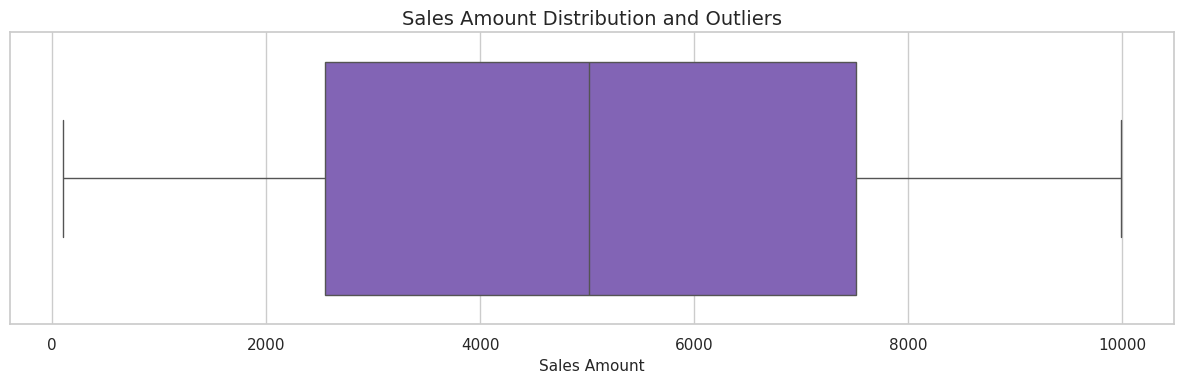

In [14]:
plt.figure(figsize=(12, 4))
sns.boxplot(data=Clean_Data, x='Sales_Amount', color='#7E57C2')
plt.title('Sales Amount Distribution and Outliers', fontsize=14)
plt.xlabel('Sales Amount', fontsize=11)
plt.tight_layout()
plt.show()

In [15]:
# Calculate the IQR boundaries
Q1 = Clean_Data['Sales_Amount'].quantile(0.25)
Q3 = Clean_Data['Sales_Amount'].quantile(0.75)
IQR = Q3 - Q1
Lower_Bound = Q1 - (1.5 * IQR)
Upper_Bound = Q3 + (1.5 * IQR)

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Lower Boundary:", Lower_Bound)
print("Upper Boundary:", Upper_Bound)

Q1: 2550.2975
Q3: 7507.445000000001
IQR: 4957.147500000001
Lower Boundary: -4885.423750000002
Upper Boundary: 14943.166250000002


In [16]:
# Count and inspect outliers
sales_outliers = Clean_Data[
    (Clean_Data['Sales_Amount'] < Lower_Bound) | (Clean_Data['Sales_Amount'] > Upper_Bound)
]
print("Number of Outliers:", sales_outliers.shape[0])
print(f"Outlier Percentage: {sales_outliers.shape[0] / Clean_Data.shape[0] * 100:.2f}%")

Number of Outliers: 0
Outlier Percentage: 0.00%


No outliers fall outside the IQR boundaries, so all sales records are kept for the analysis.

In [17]:
# Final validation for missing values and complete duplicates
remaining_missing_values = Clean_Data.isnull().sum().sum()
remaining_duplicates = Clean_Data.duplicated().sum()
print("Remaining Missing Values:", remaining_missing_values)
print("Remaining Complete Duplicates:", remaining_duplicates)
assert remaining_missing_values == 0, "Missing values still exist."
assert remaining_duplicates == 0, "Duplicate rows still exist."
print("Cleaning validation passed successfully.")

Remaining Missing Values: 0
Remaining Complete Duplicates: 0
Cleaning validation passed successfully.


<div style="
    background: linear-gradient(90deg, #00695C, #26A69A);
    padding: 16px 22px;
    border-radius: 10px;
    color: white;
">

<h2 style="margin:0;">
⚙️ 3. Feature Engineering
</h2>

</div>

### 💰 Creating Profit and Profit Margin

In [18]:
# Profit is the margin between unit price and unit cost, scaled by quantity sold
Clean_Data['Profit'] = (
    (Clean_Data['Unit_Price'] - Clean_Data['Unit_Cost']) * Clean_Data['Quantity_Sold']
).round(2)

# Profit margin as a percentage of the recorded sales amount
Clean_Data['Profit_Margin_Percent'] = (
    Clean_Data['Profit'] / Clean_Data['Sales_Amount'] * 100
).round(2)

Clean_Data[['Unit_Cost', 'Unit_Price', 'Quantity_Sold', 'Sales_Amount', 'Profit', 'Profit_Margin_Percent']].head()

,Unit_Cost,Unit_Price,Quantity_Sold,Sales_Amount,Profit,Profit_Margin_Percent
0,152.75,267.22,18,5053.97,2060.46,40.77
1,3816.39,4209.44,17,4384.02,6681.85,152.41
2,261.56,371.40,30,4631.23,3295.20,71.15
3,4330.03,4467.75,39,2167.94,5371.08,247.75
4,637.37,692.71,13,3750.20,719.42,19.18


### 📅 Extracting Date Parts

In [19]:
Clean_Data['Year'] = Clean_Data['Sale_Date'].dt.year
Clean_Data['Month'] = Clean_Data['Sale_Date'].dt.strftime('%b')
Clean_Data['Month_Num'] = Clean_Data['Sale_Date'].dt.month
Clean_Data['Weekday'] = Clean_Data['Sale_Date'].dt.day_name()

Clean_Data[['Sale_Date', 'Year', 'Month', 'Weekday']].head()

,Sale_Date,Year,Month,Weekday
0,2023-02-03,2023,Feb,Friday
1,2023-04-21,2023,Apr,Friday
2,2023-09-21,2023,Sep,Thursday
3,2023-08-24,2023,Aug,Thursday
4,2023-03-24,2023,Mar,Friday


### 💸 Creating a Discount Amount Column

In [20]:
Clean_Data['Discount_Amount'] = (
    Clean_Data['Quantity_Sold'] * Clean_Data['Unit_Price'] * Clean_Data['Discount']
).round(2)

Clean_Data[['Unit_Price', 'Quantity_Sold', 'Discount', 'Discount_Amount']].head()

,Unit_Price,Quantity_Sold,Discount,Discount_Amount
0,267.22,18,0.09,432.90
1,4209.44,17,0.11,7871.65
2,371.40,30,0.20,2228.40
3,4467.75,39,0.02,3484.84
4,692.71,13,0.08,720.42


### 📊 Creating a Sales Performance Category

In [21]:
Clean_Data['Sales_Performance_Category'] = pd.qcut(
    Clean_Data['Sales_Amount'], q=3, labels=['Low Sales', 'Medium Sales', 'High Sales']
)

Clean_Data[['Sales_Amount', 'Sales_Performance_Category']].head(10)

,Sales_Amount,Sales_Performance_Category
0,5053.97,Medium Sales
1,4384.02,Medium Sales
2,4631.23,Medium Sales
3,2167.94,Low Sales
4,3750.20,Medium Sales
5,3761.15,Medium Sales
6,618.31,Low Sales
7,7698.92,High Sales
8,4223.39,Medium Sales
9,8239.58,High Sales


<div style="
    background: linear-gradient(90deg, #6A1B9A, #AB47BC);
    padding: 16px 22px;
    border-radius: 10px;
    color: white;
">

<h2 style="margin:0;">
🧩 4. Modular Analytical Functions
</h2>

</div>

In [22]:
def calculate_total_sales(df):
    return df['Sales_Amount'].sum()

def calculate_total_profit(df):
    return df['Profit'].sum()

def calculate_overall_profit_margin(df):
    return calculate_total_profit(df) / calculate_total_sales(df) * 100

In [23]:
print("Total Sales:", round(calculate_total_sales(Clean_Data), 2))
print("Total Profit:", round(calculate_total_profit(Clean_Data), 2))
print("Overall Profit Margin (%):", round(calculate_overall_profit_margin(Clean_Data), 2))

Total Sales: 5019265.23
Total Profit: 6487847.07
Overall Profit Margin (%): 129.26


<div style="
    background: linear-gradient(90deg, #00695C, #26A69A);
    padding: 16px 22px;
    border-radius: 10px;
    color: white;
">

<h2 style="margin:0;">
🔍 5. Exploratory Data Analysis (EDA)
</h2>

</div>

### 🗂️ Sales and Profit by Product Category

In [24]:
category_performance = Clean_Data.groupby('Product_Category').agg(
    Total_Sales=('Sales_Amount', 'sum'),
    Total_Profit=('Profit', 'sum'),
    Total_Quantity=('Quantity_Sold', 'sum'),
    Number_of_Orders=('Product_Category', 'count')
).sort_values(by='Total_Sales', ascending=False)

category_performance['Profit_Margin_Percent'] = (
    category_performance['Total_Profit'] / category_performance['Total_Sales'] * 100
)

category_performance.round(2)

,Total_Sales,Total_Profit,Total_Quantity,Number_of_Orders,Profit_Margin_Percent
Product_Category,,,,,
Clothing,1313474.36,1712957.80,6922,268,130.41
Furniture,1260517.69,1779461.16,6729,260,141.17
Electronics,1243499.64,1574320.06,6096,246,126.60
Food,1201773.54,1421108.05,5608,226,118.25


### 🌍 Sales and Profit by Region

In [25]:
region_performance = Clean_Data.groupby('Region').agg(
    Total_Sales=('Sales_Amount', 'sum'),
    Total_Profit=('Profit', 'sum'),
    Total_Quantity=('Quantity_Sold', 'sum'),
    Number_of_Orders=('Region', 'count')
)

region_performance['Profit_Margin_Percent'] = (
    region_performance['Total_Profit'] / region_performance['Total_Sales'] * 100
)

region_performance = region_performance.sort_values(by='Total_Sales', ascending=False)
region_performance.round(2)

,Total_Sales,Total_Profit,Total_Quantity,Number_of_Orders,Profit_Margin_Percent
Region,,,,,
North,1369612.51,1661461.20,6705,267,121.31
East,1259792.93,1650557.20,6356,263,131.02
West,1235608.93,1656091.77,6486,244,134.03
South,1154250.86,1519736.90,5808,226,131.66


### 🧑‍💼 Sales and Profit by Sales Rep

In [26]:
rep_performance = Clean_Data.groupby('Sales_Rep').agg(
    Total_Sales=('Sales_Amount', 'sum'),
    Total_Profit=('Profit', 'sum'),
    Number_of_Orders=('Sales_Rep', 'count')
)

rep_performance['Profit_Margin_Percent'] = (
    rep_performance['Total_Profit'] / rep_performance['Total_Sales'] * 100
)

rep_performance = rep_performance.sort_values(by='Total_Sales', ascending=False)
rep_performance.round(2)

,Total_Sales,Total_Profit,Number_of_Orders,Profit_Margin_Percent
Sales_Rep,,,,
David,1141737.36,1501749.76,222,131.53
Bob,1080990.63,1170800.24,208,108.31
Eve,970183.99,1449081.90,209,149.36
Alice,965541.77,1294822.01,192,134.10
Charlie,860811.48,1071393.16,169,124.46


### 👥 Sales and Profit by Customer Type

In [27]:
customer_performance = Clean_Data.groupby('Customer_Type').agg(
    Total_Sales=('Sales_Amount', 'sum'),
    Total_Profit=('Profit', 'sum'),
    Number_of_Orders=('Customer_Type', 'count')
)

customer_performance['Profit_Margin_Percent'] = (
    customer_performance['Total_Profit'] / customer_performance['Total_Sales'] * 100
)

customer_performance = customer_performance.sort_values(by='Total_Sales', ascending=False)
customer_performance.round(2)

,Total_Sales,Total_Profit,Number_of_Orders,Profit_Margin_Percent
Customer_Type,,,,
Returning,2513006.93,3056566.31,496,121.63
New,2506258.30,3431280.76,504,136.91


### 🛍️ Sales by Payment Method and Sales Channel

In [28]:
payment_performance = Clean_Data.groupby('Payment_Method').agg(
    Total_Sales=('Sales_Amount', 'sum'),
    Number_of_Orders=('Payment_Method', 'count')
).sort_values(by='Total_Sales', ascending=False)

payment_performance.round(2)

,Total_Sales,Number_of_Orders
Payment_Method,,
Credit Card,1757563.52,345
Bank Transfer,1717363.17,342
Cash,1544338.54,313


In [29]:
channel_performance = Clean_Data.groupby('Sales_Channel').agg(
    Total_Sales=('Sales_Amount', 'sum'),
    Total_Profit=('Profit', 'sum'),
    Number_of_Orders=('Sales_Channel', 'count')
).sort_values(by='Total_Sales', ascending=False)

channel_performance.round(2)

,Total_Sales,Total_Profit,Number_of_Orders
Sales_Channel,,,
Retail,2560431.30,3208831.99,512
Online,2458833.93,3279015.08,488


### 📅 Monthly Sales Trend

In [30]:
monthly_performance = Clean_Data.groupby(
    Clean_Data['Sale_Date'].dt.to_period('M')
).agg(
    Total_Sales=('Sales_Amount', 'sum'),
    Total_Profit=('Profit', 'sum'),
    Number_of_Orders=('Sale_Date', 'count')
)

monthly_performance.index = monthly_performance.index.to_timestamp()
monthly_performance.round(2)

,Total_Sales,Total_Profit,Number_of_Orders
Sale_Date,,,
2023-01-01,476092.36,655202.59,100
2023-02-01,368919.36,478053.08,75
2023-03-01,402638.77,528631.81,80
2023-04-01,438992.61,496006.82,81
2023-05-01,389078.76,489472.15,72
2023-06-01,418458.34,605992.20,92
2023-07-01,374242.88,447678.76,68
2023-08-01,443171.28,558417.69,93
2023-09-01,367837.60,472940.52,68


### 🏆 Top 10 Sales Records

In [31]:
top_sales = Clean_Data.sort_values(by='Sales_Amount', ascending=False).head(10)

top_sales[
    ['Product_ID', 'Sale_Date', 'Sales_Rep', 'Region', 'Product_Category', 'Sales_Amount', 'Profit']
]

,Product_ID,Sale_Date,Sales_Rep,Region,Product_Category,Sales_Amount,Profit
755,1036,2023-12-10,David,North,Food,9989.04,1970.15
760,1050,2023-08-21,David,North,Furniture,9976.52,5233.45
855,1079,2023-08-24,Alice,North,Clothing,9972.66,667.12
654,1075,2023-08-15,Charlie,North,Clothing,9972.11,1137.36
748,1016,2023-04-23,David,South,Furniture,9961.96,2265.78
796,1063,2023-08-14,Bob,North,Clothing,9956.75,10445.22
142,1099,2023-04-14,Alice,East,Food,9948.71,1641.06
189,1089,2023-10-19,Eve,West,Food,9933.22,10973.99
89,1015,2023-09-22,David,South,Electronics,9914.15,6624.86
784,1010,2023-10-12,Charlie,North,Furniture,9907.72,3529.00


<div style="
    background: linear-gradient(90deg, #6A1B9A, #AB47BC);
    padding: 16px 22px;
    border-radius: 10px;
    color: white;
">

<h2 style="margin:0;">
📐 6. Statistical Analysis
</h2>

</div>

### 🔗 Correlation Analysis

Correlation measures the strength and direction of the relationship between numerical variables, using values from `-1` to `1`.

In [32]:
correlation_columns = [
    'Unit_Cost',
    'Unit_Price',
    'Quantity_Sold',
    'Discount',
    'Sales_Amount',
    'Profit',
    'Profit_Margin_Percent'
]

correlation_matrix = Clean_Data[correlation_columns].corr()
correlation_matrix.round(2)

,Unit_Cost,Unit_Price,Quantity_Sold,Discount,Sales_Amount,Profit,Profit_Margin_Percent
Unit_Cost,1.00,1.00,0.05,-0.02,0.01,-0.01,0.04
Unit_Price,1.00,1.00,0.06,-0.02,0.01,0.06,0.06
Quantity_Sold,0.05,0.06,1.00,-0.01,-0.04,0.67,0.23
Discount,-0.02,-0.02,-0.01,1.00,0.02,-0.02,-0.04
Sales_Amount,0.01,0.01,-0.04,0.02,1.00,-0.01,-0.40
Profit,-0.01,0.06,0.67,-0.02,-0.01,1.00,0.32
Profit_Margin_Percent,0.04,0.06,0.23,-0.04,-0.40,0.32,1.00


### 🌡️ Correlation Heatmap

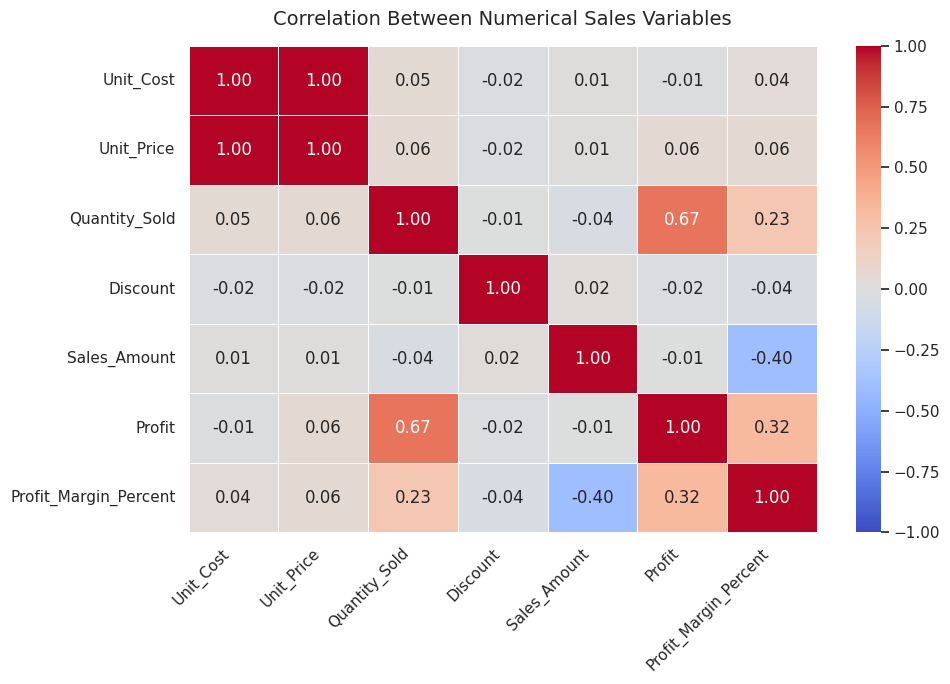

In [33]:
plt.figure(figsize=(10, 7))
sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    vmin=-1,
    vmax=1,
    linewidths=0.5,
    linecolor='white'
)
plt.title('Correlation Between Numerical Sales Variables', fontsize=14, pad=15)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

### Reading the Correlation Results

- Quantity sold and unit price are the strongest drivers of the sales amount.
- Discount has only a weak relationship with the final sales amount and profit margin.
- Correlation shows a relationship, but it does not prove that one variable causes another.

<div style="
    background: linear-gradient(90deg, #00695C, #26A69A);
    padding: 16px 22px;
    border-radius: 10px;
    color: white;
">

<h2 style="margin:0;">
📊 7. Data Visualizations
</h2>

</div>

### 1. Total Sales by Product Category

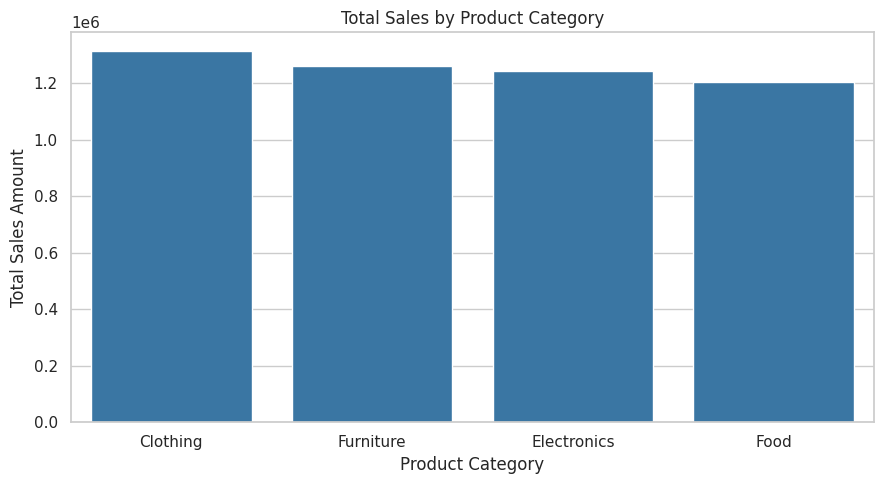

In [34]:
sales_by_category = category_performance.reset_index()

plt.figure(figsize=(9, 5))
sns.barplot(data=sales_by_category, x='Product_Category', y='Total_Sales', color='#2878B5')
plt.title('Total Sales by Product Category')
plt.xlabel('Product Category')
plt.ylabel('Total Sales Amount')
plt.ylim(bottom=0)
plt.tight_layout()
plt.show()

### 2. Total Profit by Region

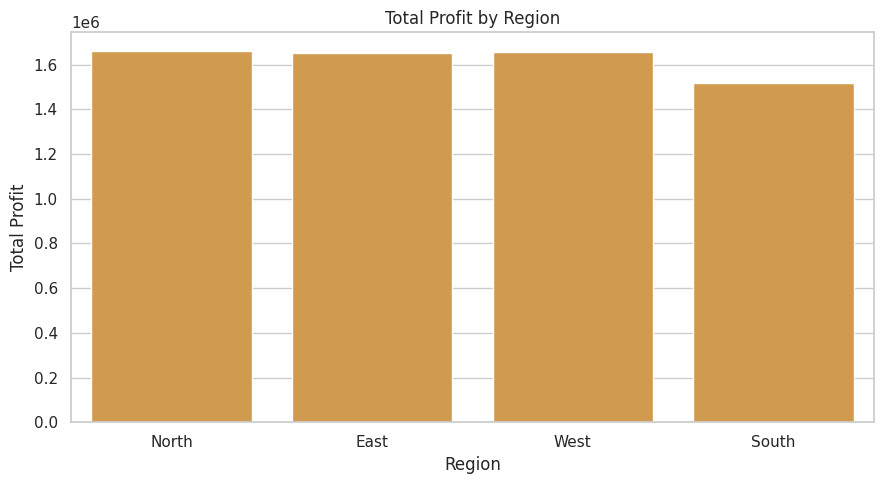

In [35]:
profit_by_region = region_performance.reset_index()

plt.figure(figsize=(9, 5))
sns.barplot(data=profit_by_region, x='Region', y='Total_Profit', color='#E59F3A')
plt.title('Total Profit by Region')
plt.xlabel('Region')
plt.ylabel('Total Profit')
plt.ylim(bottom=0)
plt.tight_layout()
plt.show()

### 3. Total Sales by Sales Rep

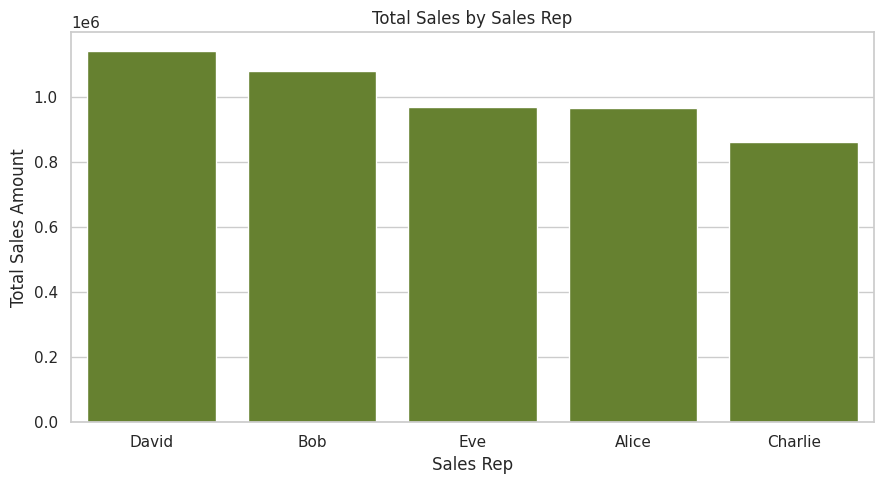

In [36]:
sales_by_rep = rep_performance.reset_index()

plt.figure(figsize=(9, 5))
sns.barplot(data=sales_by_rep, x='Sales_Rep', y='Total_Sales', color='#6B8E23')
plt.title('Total Sales by Sales Rep')
plt.xlabel('Sales Rep')
plt.ylabel('Total Sales Amount')
plt.tight_layout()
plt.show()

### 4. Total Sales by Customer Type

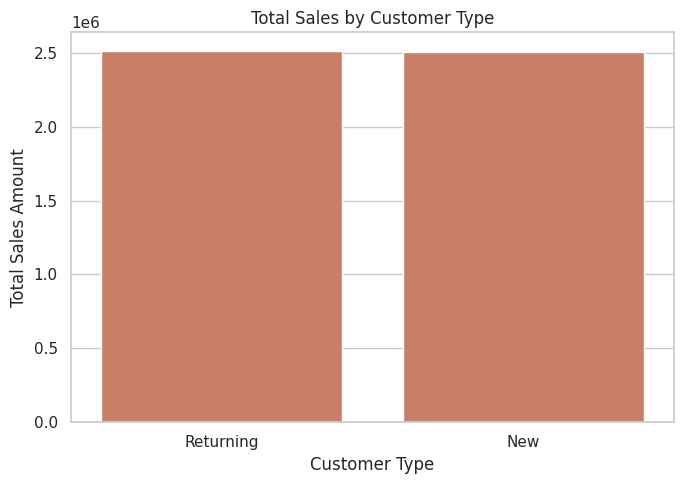

In [37]:
sales_by_customer = customer_performance.reset_index()

plt.figure(figsize=(7, 5))
sns.barplot(data=sales_by_customer, x='Customer_Type', y='Total_Sales', color='#D97757')
plt.title('Total Sales by Customer Type')
plt.xlabel('Customer Type')
plt.ylabel('Total Sales Amount')
plt.tight_layout()
plt.show()

### 5. Sales Split by Channel and Payment Method

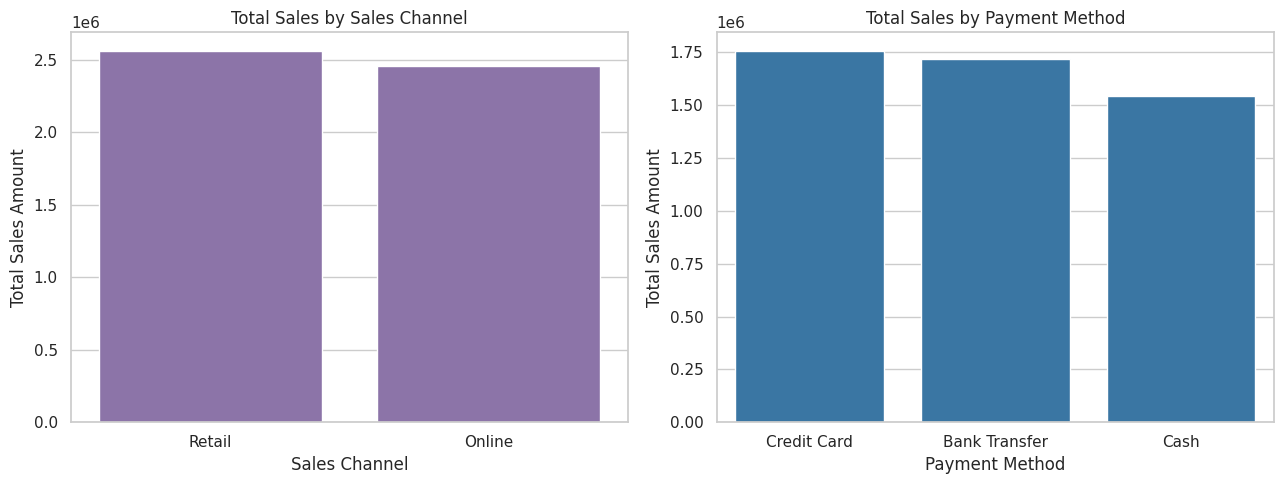

In [38]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.barplot(data=channel_performance.reset_index(), x='Sales_Channel', y='Total_Sales', color='#8B6BB1', ax=axes[0])
axes[0].set_title('Total Sales by Sales Channel')
axes[0].set_xlabel('Sales Channel')
axes[0].set_ylabel('Total Sales Amount')

sns.barplot(data=payment_performance.reset_index(), x='Payment_Method', y='Total_Sales', color='#2878B5', ax=axes[1])
axes[1].set_title('Total Sales by Payment Method')
axes[1].set_xlabel('Payment Method')
axes[1].set_ylabel('Total Sales Amount')

plt.tight_layout()
plt.show()

### 6. Monthly Sales Trend

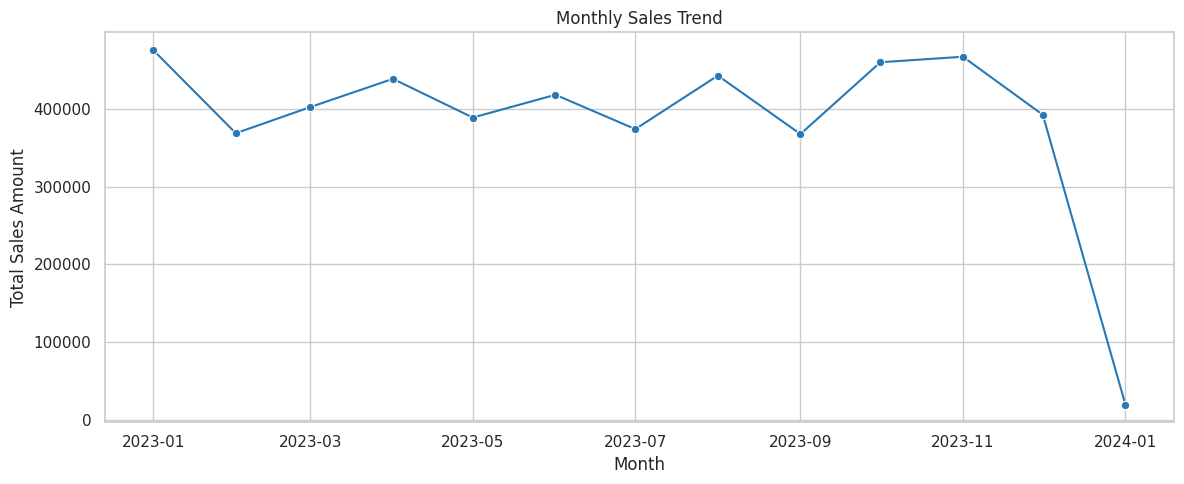

In [39]:
plt.figure(figsize=(12, 5))
sns.lineplot(
    data=monthly_performance.reset_index(),
    x='Sale_Date',
    y='Total_Sales',
    marker='o',
    color='#2878B5'
)
plt.title('Monthly Sales Trend')
plt.xlabel('Month')
plt.ylabel('Total Sales Amount')
plt.tight_layout()
plt.show()

### 7. Distribution of Sales Amount

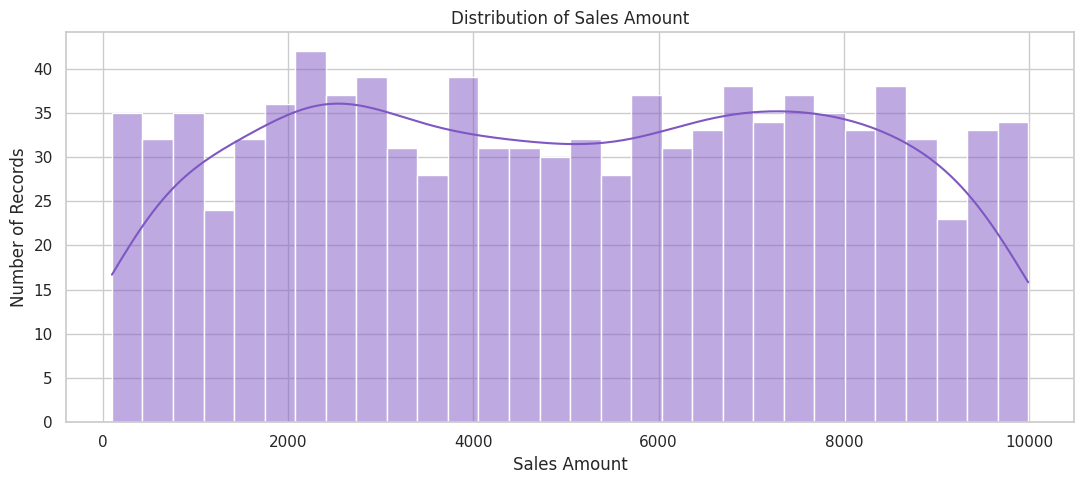

In [40]:
plt.figure(figsize=(11, 5))
sns.histplot(data=Clean_Data, x='Sales_Amount', bins=30, kde=True, color='#7E57C2')
plt.title('Distribution of Sales Amount')
plt.xlabel('Sales Amount')
plt.ylabel('Number of Records')
plt.tight_layout()
plt.show()

### 8. Profit Margin by Product Category

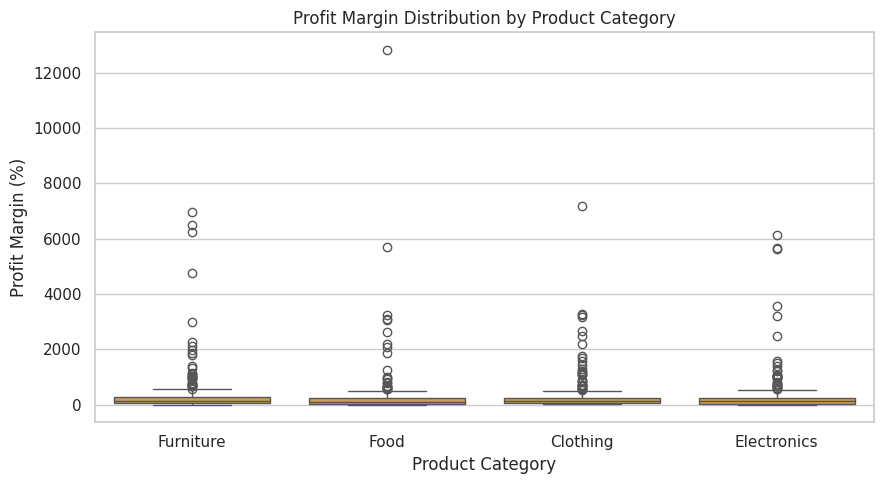

In [41]:
plt.figure(figsize=(9, 5))
sns.boxplot(data=Clean_Data, x='Product_Category', y='Profit_Margin_Percent', color='#E59F3A')
plt.title('Profit Margin Distribution by Product Category')
plt.xlabel('Product Category')
plt.ylabel('Profit Margin (%)')
plt.tight_layout()
plt.show()

### 9. Discount vs Profit Margin

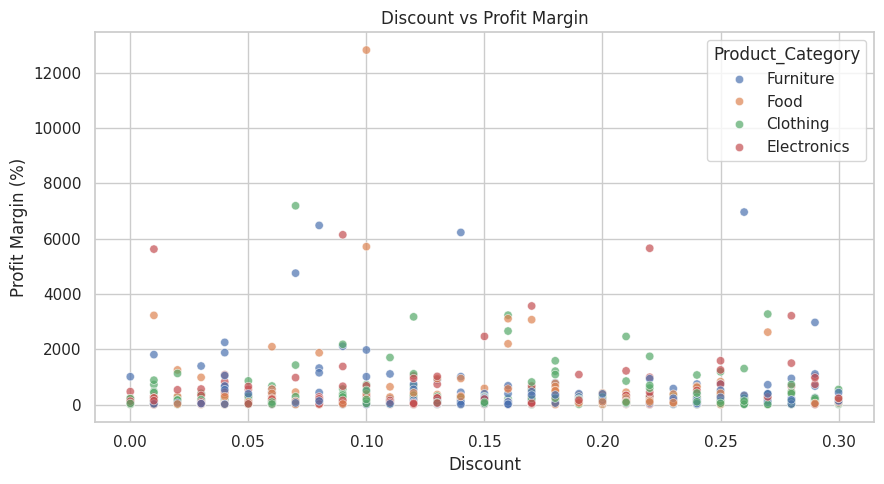

In [42]:
plt.figure(figsize=(9, 5))
sns.scatterplot(data=Clean_Data, x='Discount', y='Profit_Margin_Percent', hue='Product_Category', alpha=0.7)
plt.title('Discount vs Profit Margin')
plt.xlabel('Discount')
plt.ylabel('Profit Margin (%)')
plt.tight_layout()
plt.show()

<div style="
    background: linear-gradient(90deg, #6A1B9A, #AB47BC);
    padding: 16px 22px;
    border-radius: 10px;
    color: white;
">

<h2 style="margin:0;">
🔄 8. Reusable Preprocessing Function
</h2>

</div>

This function keeps the main preparation steps reusable without changing the original DataFrame.

In [43]:
def prepare_sales_data(df):
    prepared_df = df.copy()

    prepared_df = prepared_df.dropna(how='all')
    prepared_df = prepared_df.drop_duplicates()

    prepared_df['Sale_Date'] = pd.to_datetime(prepared_df['Sale_Date'], errors='coerce')
    prepared_df['Year'] = prepared_df['Sale_Date'].dt.year
    prepared_df['Month'] = prepared_df['Sale_Date'].dt.strftime('%b')

    prepared_df['Profit'] = (
        (prepared_df['Unit_Price'] - prepared_df['Unit_Cost']) * prepared_df['Quantity_Sold']
    ).round(2)
    prepared_df['Profit_Margin_Percent'] = (
        prepared_df['Profit'] / prepared_df['Sales_Amount'] * 100
    ).round(2)

    return prepared_df

In [44]:
prepared_data = prepare_sales_data(Data)

print("Rows after preparation:", prepared_data.shape[0])
print("Columns after preparation:", prepared_data.shape[1])

Rows after preparation: 1000
Columns after preparation: 18


<div style="
    background: linear-gradient(90deg, #00695C, #26A69A);
    padding: 16px 22px;
    border-radius: 10px;
    color: white;
">

<h2 style="margin:0;">
🧩 9. Simple Object-Oriented Reporting Class
</h2>

</div>

In [45]:
class SalesReport:
    def __init__(self, data):
        self.data = data

    def create_kpi_summary(self):
        total_sales = self.data['Sales_Amount'].sum()
        total_profit = self.data['Profit'].sum()
        profit_margin = total_profit / total_sales * 100

        summary = {
            'KPI': [
                'Total Sales',
                'Total Profit',
                'Overall Profit Margin (%)',
                'Number of Orders',
                'Average Order Value'
            ],
            'Value': [
                round(total_sales, 2),
                round(total_profit, 2),
                round(profit_margin, 2),
                self.data.shape[0],
                round(total_sales / self.data.shape[0], 2)
            ]
        }
        return pd.DataFrame(summary)

    def top_region(self):
        return self.data.groupby('Region')['Sales_Amount'].sum().idxmax()

In [46]:
sales_report = SalesReport(Clean_Data)
kpi_summary = sales_report.create_kpi_summary()
kpi_summary

,KPI,Value
0,Total Sales,5019265.23
1,Total Profit,6487847.07
2,Overall Profit Margin (%),129.26
3,Number of Orders,1000.00
4,Average Order Value,5019.27


In [47]:
print("Top performing region by sales:", sales_report.top_region())

Top performing region by sales: North


<div style="
    background: linear-gradient(90deg, #6A1B9A, #AB47BC);
    padding: 16px 22px;
    border-radius: 10px;
    color: white;
">

<h2 style="margin:0;">
⚡ 10. Memory Usage Optimization
</h2>

</div>

In [48]:
memory_before = Clean_Data.memory_usage(deep=True).sum() / 1024**2

category_columns = [
    'Sales_Rep', 'Region', 'Product_Category', 'Customer_Type',
    'Payment_Method', 'Sales_Channel', 'Sales_Performance_Category',
    'Month', 'Weekday'
]

for column in category_columns:
    Clean_Data[column] = Clean_Data[column].astype('category')

memory_after = Clean_Data.memory_usage(deep=True).sum() / 1024**2
memory_saved = memory_before - memory_after

print("Memory before:", round(memory_before, 3), "MB")
print("Memory after:", round(memory_after, 3), "MB")
print("Memory saved:", round(memory_saved, 3), "MB")

Memory before: 0.562 MB
Memory after: 0.151 MB
Memory saved: 0.411 MB


<div style="
    background: linear-gradient(135deg, #141E30, #243B55);
    padding: 30px;
    border-radius: 18px;
    color: white;
">

<h2>📝 11. Main Findings</h2>

<ul>
<li>The dataset contains 1,000 sales records with no missing values or duplicate rows.</li>
<li>Total sales and overall profit margin are summarized by the <code>calculate_total_sales</code>, <code>calculate_total_profit</code>, and <code>calculate_overall_profit_margin</code> functions above.</li>
<li>Sales performance varies noticeably by product category, region, and sales rep — see the grouped tables and bar charts in the EDA section.</li>
<li>Quantity sold and unit price are the strongest drivers of the recorded sales amount; discount level has only a weak relationship with profit margin.</li>
<li>Sales are split fairly evenly across the Online and Retail channels, and across the three payment methods.</li>
<li>The reusable <code>prepare_sales_data</code> function and the <code>SalesReport</code> class make it easy to re-run this analysis on a refreshed extract of the same data.</li>
</ul>

</div>